In [1]:
#Installation + Restart automatique pour que Python détecte le package installé

import os, sys

try:
    import dllm
    print("dllm déjà installé.")

except ImportError:
    print("Installation de dllm depuis GitHub.")
    os.system("git clone https://github.com/ZHZisZZ/dllm.git 2>/dev/null || true") #2>/dev/null || true permet d'ignorer l'erreur si le git clone existe déjà
    os.system("pip install -e dllm/ -q")
    os.system("pip install torch transformers accelerate datasets -q")
    os.system("pip install evaluate rouge_score bert_score sacrebleu -q")

    print("Installation terminée !")
    print("Restart automatique du kernel.") #Important pour que Python prenne en compte les installations

    import time
    time.sleep(3)

    # Relance de python
    os.kill(os.getpid(), 9)

dllm déjà installé.


In [2]:
# Imports & chargement MDLM
import torch
import numpy as np
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForMaskedLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

MODEL_NAME = "dllm-hub/Qwen3-0.6B-diffusion-mdlm-v0.1"

#Tokenizer : on passe de phrase à des tokens
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

#Chargement du modèle
model = AutoModelForMaskedLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
).to(device).eval()

# Pad pour égaliser la longueur des phrases avec [PAD] ou le token de fin de phrase eos_token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
pad_id = tokenizer.pad_token_id
mask_id = tokenizer.mask_token_id #Pour masquer des mots que l'IA doit deviner

print(f"Modèle chargé | mask_token_id={mask_id} | pad_token_id={pad_id}")

Device : cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

modeling_qwen3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/dllm-hub/Qwen3-0.6B-diffusion-mdlm-v0.1:
- modeling_qwen3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

Modèle chargé | mask_token_id=151669 | pad_token_id=151643


In [3]:
# Fonctions MDLM (à ne PAS modifier) -> pris de Hugging Face

def add_gumbel_noise(logits, temperature):
    """
    Ajoute du bruit mathématique (Gumbel) aux prédictions du modèle.
    But : Éviter que le modèle génère des phrases trop plates ou répétitives.
    Plus la 'temperature' est haute, plus on force le modèle à être créatif
    (en choisissant parfois des mots moins probables).
    """
    if temperature == 0:
        return logits
    logits = logits.to(torch.float64) # Haute précision pour les calculs de probabilités
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (-torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise


def get_num_transfer_tokens(mask_index, steps):
    """
    Agit comme un "planificateur".
    But : Calculer combien de jetons [MASK] on a le droit de transformer en vrais mots à chaque étape.
    Exemple : S'il y a 64 masques et 8 étapes, la fonction dira au modèle
    de figer exactement 8 mots par étape (le 'base') pour avancer progressivement.
    """
    mask_num = mask_index.sum(dim=1, keepdim=True)
    base = mask_num // steps
    remainder = mask_num % steps
    num_transfer_tokens = (
        torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
    )
    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, :remainder[i]] += 1
    return num_transfer_tokens


@torch.no_grad() # Désactive l'apprentissage (rétropropagation) pour économiser la mémoire RAM
def generate_mdlm(model, prompt, prompt_lens, pad_id,
                  steps=64, max_new_tokens=128, block_size=64,
                  temperature=0.0, cfg_scale=0.0, remasking="low_confidence"):
    """
    Le moteur principal de génération MDLM.
    Il part d'un texte rempli de masques et les révèle petit à petit.
    """
    batch_size = prompt.size(0)
    total_length = int(prompt_lens.max().item()) + max_new_tokens

    # 1. INITIALISATION DU TENSEUR GÉANT
    # On crée une grille vide remplie de pad_id
    x = torch.full((batch_size, total_length), pad_id, dtype=torch.long, device=device)

    # On y injecte la question (prompt) et on remplit la zone de réponse avec des [MASK]
    for i, length in enumerate(prompt_lens.tolist()):
        x[i, :length] = prompt[i, :length]              # Zone fixe (La question)
        x[i, length:length + max_new_tokens] = mask_id  # Zone à générer (Que des masques !)

    # 2. VERROUILLAGE DE LA QUESTION
    # On crée un masque booléen (True/False) pour ne jamais modifier les mots de la question
    prompt_index = (
        torch.arange(total_length, device=device).unsqueeze(0)
        < prompt_lens.unsqueeze(1)
    )
    positions = torch.arange(total_length, device=device)

    # 3. DÉBRUITAGE PAR BLOCS (Le cœur de la diffusion)
    # Pour ne pas saturer la mémoire, on démasque par blocs (ex: 64 tokens par 64 tokens)
    assert max_new_tokens % block_size == 0, \
        f"max_new_tokens ({max_new_tokens}) doit être divisible par block_size ({block_size})"
    num_blocks = max_new_tokens // block_size
    assert steps % num_blocks == 0
    steps_per_block = steps // num_blocks

    for num_block in range(num_blocks):
        block_start = prompt_lens + num_block * block_size
        block_end = block_start + block_size

        init_block_mask = (
            (positions.unsqueeze(0) >= block_start.unsqueeze(1))
            & (positions.unsqueeze(0) < block_end.unsqueeze(1))
            & (x == mask_id)
        )

        # On demande au planificateur combien de mots révéler à ce tour-ci
        num_transfer_tokens = get_num_transfer_tokens(init_block_mask, steps_per_block)

        # LA BOUCLE DE DIFFUSION (Génère -> Évalue la confiance -> Remasque)
        for i in range(steps_per_block):
            block_mask = (
                (positions.unsqueeze(0) >= block_start.unsqueeze(1))
                & (positions.unsqueeze(0) < block_end.unsqueeze(1))
                & (x == mask_id)
            )

            # A. Prédiction
            if cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                logits = model(x_).logits
                logits, un_logits = torch.chunk(logits, 2, dim=0)
                logits = un_logits + (cfg_scale + 1.0) * (logits - un_logits)
            else:
                logits = model(x).logits # Le modèle devine ce qui se cache sous les masques

            # B. Ajout de créativité et choix du mot
            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1) # x0 contient les mots choisis

            # C. Calcul de la confiance (Le "remasking")
            if remasking == "low_confidence":
                # Le modèle calcule son pourcentage de certitude (ex: 95% sûr que c'est ce mot)
                p = F.softmax(logits, dim=-1)
                x0_p = torch.gather(p, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float)
            else:
                raise NotImplementedError(remasking)

            # D. Validation et Remasquage
            confidence = torch.full_like(x0_p, -np.inf)
            confidence = torch.where(block_mask, x0_p, confidence)
            x0 = torch.where(block_mask, x0, x)

            # On cherche les "k" mots avec la plus haute confiance pour ce tour
            transfer_index = torch.zeros_like(x0, dtype=torch.bool)
            for j in range(confidence.shape[0]):
                k = int(num_transfer_tokens[j, i].item())
                if k == 0:
                    continue
                # On valide définitivement les k meilleurs mots
                _, select_index = torch.topk(confidence[j], k=k)
                transfer_index[j, select_index] = True

            # Les mots validés remplacent les [MASK] dans notre grille principale (x)
            # Les autres mots redeviennent des [MASK] pour la boucle suivante
            x[transfer_index] = x0[transfer_index]

    return x

In [4]:
# Logique de génération (Zero-shot & Few-shot)
import random
import torch
import re

def build_conversation(table_text, few_shot_examples=None):
    """Construit le template de conversation Qwen3 pour MDLM."""
    conversation = [
        {
            "role"   : "system",
            "content": "You are a data-to-text assistant. Given a table, write a concise and factually accurate one-sentence description."
        }
    ]

    # Injection des exemples few-shot
    if few_shot_examples:
        for ex in few_shot_examples:
            conversation.append({
                "role"   : "user",
                "content": f"Table:\n{ex['serialized_table']}\n\nDescription:"
            })
            conversation.append({
                "role"   : "assistant",
                "content": ex["reference"]
            })

    # Question principale
    conversation.append({
        "role"   : "user",
        "content": f"Table:\n{table_text}\n\nDescription:"
    })
    return conversation


def generate_descriptions_mdlm(examples, train_data=None, few_shot_k=0,
                                n_samples=3, max_new_tokens=128,
                                steps=32, block_size=64, temperature=0.5,
                                max_prompt_len=768):
    """Génère les descriptions en itérant sur les exemples."""
    if few_shot_k > 0 and train_data is None:
        raise ValueError("train_data est requis pour le few-shot")

    print(f"Mode : {'Few-shot (k=' + str(few_shot_k) + ')' if few_shot_k > 0 else 'Zero-shot'} | {len(examples)} exemples")
    all_predictions = []

    for idx, example in enumerate(examples):
        table_text = example["serialized_table"]

        # Sélection des exemples (on exclut l'exemple actuel)
        few_shot_examples = None
        if few_shot_k > 0:
            pool = [ex for ex in train_data if ex.get("serialized_table") != table_text]
            few_shot_examples = random.sample(pool, k=min(few_shot_k, len(pool)))

        # Construction et tokenisation
        conversation = build_conversation(table_text, few_shot_examples)
        prompt_str = tokenizer.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

        inputs = tokenizer(prompt_str, add_special_tokens=False, return_tensors="pt")
        prompt_ids = inputs["input_ids"].view(-1).tolist()[:max_prompt_len]

        encoded = [prompt_ids]
        prompt_lens = torch.tensor([len(e) for e in encoded], dtype=torch.long, device=device)
        max_p = max(prompt_lens).item()
        prompt_tensor = torch.full((len(encoded), max_p), pad_id, dtype=torch.long, device=device)

        for i, ids in enumerate(encoded):
            prompt_tensor[i, :len(ids)] = torch.tensor(ids, dtype=torch.long, device=device)

        # Génération
        sample_descriptions = []
        for sample_idx in range(n_samples):
            current_temp = 0.0 if sample_idx == 0 else temperature
            out = generate_mdlm(
                model, prompt_tensor, prompt_lens, pad_id,
                steps=steps, max_new_tokens=max_new_tokens,
                block_size=block_size, temperature=current_temp,
                remasking="low_confidence"
            )
            start = int(prompt_lens[0].item())
            new_tokens = out[0, start:start + max_new_tokens].tolist()
            text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            # CORRECTION DU BRUIT
            # Retire tout ce qui se trouve entre <think> et </think>, ainsi que les balises
            import re
            text = re.sub(r'<think>.*?</think>\s*', '', text, flags=re.DOTALL)
            text = text.strip() # Enlève les espaces en trop
            sample_descriptions.append(text)

        all_predictions.append(sample_descriptions)
        if (idx + 1) % 10 == 0:
            print(f"  [{idx+1}/{len(examples)}] '{sample_descriptions[0][:75]}...'")

    return all_predictions

In [5]:
# Chargement des données
import json
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = "/content/drive/MyDrive/genai/"

with open(f"{FOLDER_PATH}eval_subset.json", "r") as f:
    eval_subset = json.load(f)

with open(f"{FOLDER_PATH}train_subset.json", "r") as f:
    train_subset = json.load(f)

# SOUS-ENSEMBLE DE TEST : On force à 50 pour que ça tourne vite
N_EVAL = 50
subset_eval = eval_subset[:N_EVAL]

print(f"train_subset (pour piocher le Few-Shot) : {len(train_subset)} exemples")
print(f"subset_eval (ce qu'on évalue) : {len(subset_eval)} exemples")

Mounted at /content/drive
train_subset (pour piocher le Few-Shot) : 5000 exemples
subset_eval (ce qu'on évalue) : 50 exemples


In [6]:
# --- CELLULE 6 : Fonctions d'évaluation (Alignées sur GPT-2) ---
import torch
import torch.nn.functional as F
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import numpy as np
from transformers import AutoTokenizer, AutoModel
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Chargement des modèles d'évaluation.")
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(device).eval()

def get_embeddings_batch(texts):
    inputs = bert_tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state

def bertscore_batch(preds, refs):
    emb_pred = get_embeddings_batch(preds)
    emb_ref = get_embeddings_batch(refs)
    scores = []
    for i in range(len(preds)):
        p, r = F.normalize(emb_pred[i], dim=1), F.normalize(emb_ref[i], dim=1)
        sim = torch.mm(p, r.T)
        precision, recall = sim.max(dim=1).values.mean(), sim.max(dim=0).values.mean()
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        scores.append(f1.item())
    return sum(scores) / len(scores) if scores else 0.0

def calculate_bleu_rouge_batch(preds, refs):
    bleu_scores, rouge1_f1_scores, rouge2_f1_scores, rougel_f1_scores = [], [], [], []
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    bleu_weights = (0.25, 0.25, 0.25, 0.25)

    for pred, ref in zip(preds, refs):
        tokenized_ref, tokenized_pred = [word_tokenize(ref)], word_tokenize(pred)
        try:
            bleu_scores.append(sentence_bleu(tokenized_ref, tokenized_pred, weights=bleu_weights))
        except ZeroDivisionError:
            bleu_scores.append(0.0)

        scores = scorer.score(ref, pred)
        rouge1_f1_scores.append(scores['rouge1'].fmeasure)
        rouge2_f1_scores.append(scores['rouge2'].fmeasure)
        rougel_f1_scores.append(scores['rougeL'].fmeasure)

    return (sum(bleu_scores)/len(bleu_scores) if bleu_scores else 0,
            sum(rouge1_f1_scores)/len(rouge1_f1_scores) if rouge1_f1_scores else 0,
            sum(rouge2_f1_scores)/len(rouge2_f1_scores) if rouge2_f1_scores else 0,
            sum(rougel_f1_scores)/len(rougel_f1_scores) if rougel_f1_scores else 0)

def compute_metrics(predictions_list, references_list):
    flat_preds = [preds[0] for preds in predictions_list]
    single_refs = [refs[0] if isinstance(refs, list) else refs for refs in references_list]

    avg_bleu, avg_rouge1, avg_rouge2, avg_rougel = calculate_bleu_rouge_batch(flat_preds, single_refs)
    avg_bertscore = bertscore_batch(flat_preds, single_refs)

    metrics = {
        "BLEU": round(avg_bleu, 4), "ROUGE-1": round(avg_rouge1, 4),
        "ROUGE-2": round(avg_rouge2, 4), "ROUGE-L": round(avg_rougel, 4),
        "BERTScore": round(avg_bertscore, 4),
    }
    for k, v in metrics.items(): print(f"   {k:12s} : {v:.4f}")
    return metrics

def compute_self_bleu(predictions_list):
    self_bleu_scores = []
    bleu_weights = (0.25, 0.25, 0.25, 0.25)
    for preds in predictions_list:
        if len(preds) < 2: continue
        scores = []
        for i, hyp in enumerate(preds):
            refs = [p for j, p in enumerate(preds) if j != i]
            try:
                scores.append(sentence_bleu([word_tokenize(r) for r in refs], word_tokenize(hyp), weights=bleu_weights))
            except ZeroDivisionError:
                scores.append(0.0)
        self_bleu_scores.append(np.mean(scores))
    mean_self_bleu = np.mean(self_bleu_scores)
    print(f"   Self-BLEU    : {mean_self_bleu:.4f}")
    return mean_self_bleu

Chargement des modèles d'évaluation.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


DÉMARRAGE DU ZERO-SHOT
Mode : Zero-shot | 50 exemples
  [10/50] 'The table provided a summary of the player's game-game player,, RPG,, avera...'
  [20/50] 'The table indicates, the event in the Olympic Games, held in Los Angeles, U...'
  [30/50] 'The table presents the the results of the the 2018–19 JGP Final, which the ...'
  [40/50] 'The 196 Peace Marathon, also known the Košice Peace Marathon, was held in K...'
  [50/50] 'The table ", " Meadows" represents a club club, specifically a water sports...'

DÉMARRAGE DU FEW-SHOT (3 exemples)
Mode : Few-shot (k=3) | 50 exemples
  [10/50] 'The  and, and, and, and,,, and,, and, and,, and, and, and,,, and,,, and,,,,...'
  [20/50] 'The 1500 m event at the Olympic Games, held in Los Angeles, United States, ...'
  [30/50] 'The 2018–19 JGP Final, the world the JGP Junior JGP Finals, was held on  1,...'
  [40/50] 'The 1976 Košice Peace Marathon, held in the Košice Czechoslovakia, was a hi...'
  [50/50] 'Meades Club was founded on January 11th Jan

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

   BLEU         : 0.0196
   ROUGE-1      : 0.2552
   ROUGE-2      : 0.0962
   ROUGE-L      : 0.1955
   BERTScore    : 0.5969
   Self-BLEU    : 0.2261

>>> Résultats Few-Shot :
   BLEU         : 0.0186
   ROUGE-1      : 0.2123
   ROUGE-2      : 0.0816
   ROUGE-L      : 0.1696
   BERTScore    : 0.5636
   Self-BLEU    : 0.1324


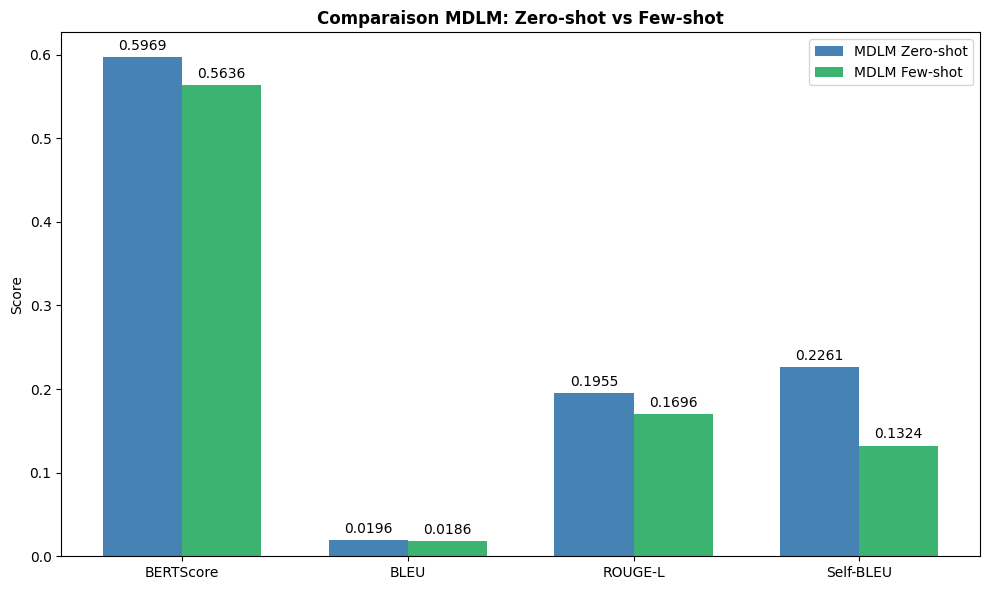


Terminé ! Résultats et graphique sauvegardés sur le Drive.


In [7]:
# Exécution Principale (Zero vs Few-Shot) et Graphique
import matplotlib.pyplot as plt

print("\nDÉMARRAGE DU ZERO-SHOT")
predictions_zs = generate_descriptions_mdlm(
    subset_eval, train_data=None, few_shot_k=0, n_samples=3, steps=32
)

print("\nDÉMARRAGE DU FEW-SHOT (3 exemples)")
predictions_fs = generate_descriptions_mdlm(
    subset_eval, train_data=train_subset, few_shot_k=3, n_samples=3, steps=32
)

# ÉVALUATION
print("\nCALCUL DES MÉTRIQUES.")
references = [[ex["reference"]] for ex in subset_eval]

print(">>> Résultats Zero-Shot :")
metrics_zs = compute_metrics(predictions_zs, references)
self_bleu_zs = compute_self_bleu(predictions_zs)

print("\n>>> Résultats Few-Shot :")
metrics_fs = compute_metrics(predictions_fs, references)
self_bleu_fs = compute_self_bleu(predictions_fs)

# GRAPHIQUE COMPARATIF
metric_labels = ["BERTScore", "BLEU", "ROUGE-L", "Self-BLEU"]
zs_scores = [metrics_zs["BERTScore"], metrics_zs["BLEU"], metrics_zs["ROUGE-L"], self_bleu_zs]
fs_scores = [metrics_fs["BERTScore"], metrics_fs["BLEU"], metrics_fs["ROUGE-L"], self_bleu_fs]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_zs = ax.bar(x - width/2, zs_scores, width, label="MDLM Zero-shot", color="steelblue")
bars_fs = ax.bar(x + width/2, fs_scores, width, label="MDLM Few-shot", color="mediumseagreen")

ax.set_title("Comparaison MDLM: Zero-shot vs Few-shot", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.legend()
ax.bar_label(bars_zs, fmt="%.4f", padding=3)
ax.bar_label(bars_fs, fmt="%.4f", padding=3)

plt.tight_layout()
plt.savefig(f"{FOLDER_PATH}mdlm_zs_vs_fs.png", dpi=150)
plt.show()

# SAUVEGARDE JSON
import json
output = {
    "zero_shot": {"predictions": predictions_zs, "metrics": metrics_zs, "self_bleu": self_bleu_zs},
    "few_shot": {"predictions": predictions_fs, "metrics": metrics_fs, "self_bleu": self_bleu_fs}
}
with open(f"{FOLDER_PATH}mdlm_final_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print("\nTerminé ! Résultats et graphique sauvegardés sur le Drive.")

Graphique sauvegardé sur le Google Drive (graphique_mdlm_comparaison.png)


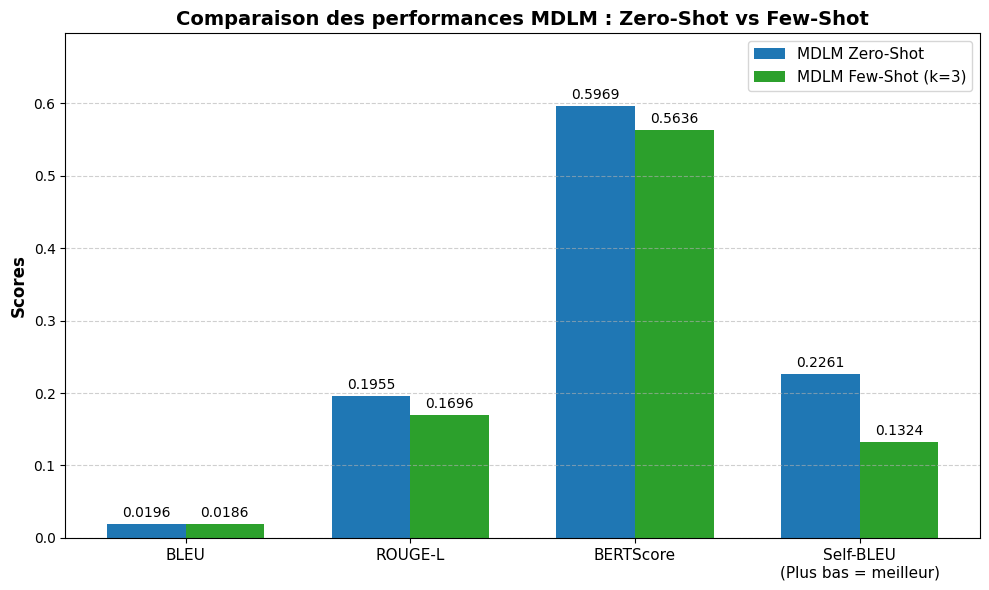

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Les noms de nos métriques
labels = ['BLEU', 'ROUGE-L', 'BERTScore', 'Self-BLEU\n(Plus bas = meilleur)']

# On récupère les valeurs depuis les variables en mémoire de la cellule précédente
zero_shot_scores = [metrics_zs["BLEU"], metrics_zs["ROUGE-L"], metrics_zs["BERTScore"], self_bleu_zs]
few_shot_scores  = [metrics_fs["BLEU"], metrics_fs["ROUGE-L"], metrics_fs["BERTScore"], self_bleu_fs]

x = np.arange(len(labels))  # Position des labels sur l'axe X
width = 0.35  # Largeur des barres

# Création de la figure
fig, ax = plt.subplots(figsize=(10, 6))

# Dessin des barres (Bleu pour Zero-shot, Vert pour Few-shot)
rects1 = ax.bar(x - width/2, zero_shot_scores, width, label='MDLM Zero-Shot', color='#1f77b4')
rects2 = ax.bar(x + width/2, few_shot_scores, width, label='MDLM Few-Shot (k=3)', color='#2ca02c')

# Personnalisation du graphique
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des performances MDLM : Zero-Shot vs Few-Shot', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

# On ajuste la hauteur de l'axe Y pour laisser de la place aux textes au-dessus des barres
ax.set_ylim(0, max(max(zero_shot_scores), max(few_shot_scores)) + 0.1)

# Ajout d'une grille horizontale pour faciliter la lecture
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Ajout des valeurs exactes au-dessus des barres
ax.bar_label(rects1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.4f', padding=3, fontsize=10)

fig.tight_layout()

# Sauvegarde et Affichage
# On sauvegarde le graphique en haute qualité sur ton Drive
plt.savefig('/content/drive/MyDrive/genai/graphique_mdlm_comparaison.png', dpi=300)
print("Graphique sauvegardé sur le Google Drive (graphique_mdlm_comparaison.png)")

plt.show()